In [1]:
# Installing dependencies if Colab
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    print("In Colab, installing dependencies", flush=True)
    !pip install biopython jaxtyping circuitsvis transformer-lens==3.0.0 torchao==0.17.0 transformers==4.57.5 datasets==4.4.2 kaleido==0.2.1

    print("Mounting Colab")
    from google.colab import drive
    drive.mount('/content/drive')
    %cd drive/MyDrive/mutational-embedding-vectors/notebooks

In Colab, installing dependencies
Mounting Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/mutational-embedding-vectors/notebooks


In [2]:
import argparse
import os
import pickle
import sys
import typing
import copy

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM,
    EsmConfig,
    PretrainedConfig,
    EsmTokenizer,
    DataCollatorForLanguageModeling,
    modeling_outputs,
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

from sklearn.linear_model import LinearRegression

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [3]:
sys.path.append("../config")
import experiment_config

In [4]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from branches import json_to_tree
import interp_utils

In [5]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile

# Investigating whether biologically redundant sites (highly conserved regions/co-varying sites) are re-used for computation

# Load $\text{ESM}_{\text{coronaviridae}}$ rather than CovFit model

In [6]:
torch.autograd.grad_mode.set_grad_enabled(False)
torch.set_float32_matmul_precision("medium")
# small thing to turn off annoying wand questions
os.environ["WANDB_DISABLED"] = "true"
CONTEXT_LEN = experiment_config.CONTEXT_LEN
device = experiment_config.device
print(f"device = {device}")

device = cuda


In [7]:
_config, _esm_covfit, (hooked_esm_covfit, get_logit_covfit) = interp_utils.setup_and_load_model(experiment_config, "covfit")
del _
del _esm_covfit
torch.cuda.empty_cache()

(covfit) esm_model <All keys matched successfully>
hooked_model:  <All keys matched successfully>
Note: covfit get_logit_hooked takes 2 inputs -- output and tok_id


In [8]:
esm_config, esm_disp, (hooked_esm, get_logit_coronaviridae) = interp_utils.setup_and_load_model(experiment_config, "coronaviridae")

(coronaviridae) esm_model:  <All keys matched successfully>
hooked_model:  <All keys matched successfully>
Note: coronaviridae get_logit_hooked takes 1 input -- output


In [9]:
tokenizer_config = {}
tokenizer_config["vocab_file"] = experiment_config.VOCAB_FILE
tokenizer_config["model_max_length"] = experiment_config.CONTEXT_LEN

with open(experiment_config.SPECIAL_TOK_MAP, "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

tokenizer = EsmTokenizer(**tokenizer_config)
original_task_id_infos = torch.load(experiment_config.TASK_IDS_FILE, map_location=device)

In [10]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"

    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

logit_id = original_task_id_infos["fitness_USA"]
# clean up memory
torch.cuda.empty_cache()

In [11]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

# Perplexities

In [12]:
# HookedTransformer wrapper to interact with HuggingFace Trainer:
# coded up (mostly) by Gemini to get around bug where HuggingFace Trainer.evaluate() function doesn't accept raw HookedTransformer datatype
class HFHookedTransformerWrapper(nn.Module):
    def __init__(self, hooked_model: HookedTransformer, lm_head=esm_disp.lm_head):
        super().__init__()
        self.model = hooked_model
        # Trainer checks configuration attributes; forward this if needed
        self.config = hooked_model.cfg
        self.lm_head = lm_head

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        # By setting return_type="loss", HookedTransformer calculates cross-entropy loss internally
        # if labels (tokens) are provided.
        if labels is not None:
            logits = self.lm_head(self.model(input_ids))
            loss = nn.functional.cross_entropy(logits.view(-1, logits.shape[-1]), labels.view(-1))
        else:
            logits = self.lm_head(self.model(input_ids))
            loss = None

        return modeling_outputs.CausalLMOutputWithPast(
            loss=loss,
            logits=logits,
        )

In [ ]:
wrapped_transformer = HFHookedTransformerWrapper(hooked_model=hooked_esm)

In [ ]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer, max_length=CONTEXT_LEN): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt",
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

In [ ]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [ ]:
pathogen_perplexities = dict()

In [ ]:
virus_dsets = ["sars_cov_2_spike", "sars_cov_2_spike_africa", "sars_cov_2_spike_asia", "sars_cov_2_spike_europe", "sars_cov_2_spike_north_america", "sars_cov_2_spike_oceania", "sars_cov_2_spike_south_america"]
# for pathogen_name in ["sars_cov_2_spike", "cov_229e_s1"]:
for pathogen_name in virus_dsets:
    fasta_file = f"../data/pathogen/{pathogen_name}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    uniq_seqs, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences


    # identical code to how it's compute_node_embeddings.py
    protein_coords = config["pathogens"][pathogen_name]["protein_coords"]
    cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
    cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming

    # create dataset
    eval_dict = {"input_ids":list(cut_seqs)}

    eval_dset = Dataset.from_dict(eval_dict)

    column_names = eval_dset.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
    eval_dataset = eval_dset.map(
        tokenizer_for_map,
        batched=True,
        # num_proc=8,
        remove_columns=column_names,
    )

    # evaluate ESM-2 model on dataset
    evaluator = Trainer(
      model=wrapped_transformer,
      data_collator=data_collator,
      eval_dataset=eval_dataset,
    )
    # evaluator = Trainer(
    #   model=esm_disp,
    #   data_collator=data_collator,
    #   eval_dataset=eval_dataset,
    # )
    eval_results = evaluator.evaluate()
    pathogen_perplexities[pathogen_name] = math.exp(eval_results['eval_loss'])
    print(f"Pathogen: {pathogen_name}\nESM-2 Perplexity: {pathogen_perplexities[pathogen_name]:.4f}\n")

In [ ]:
uniref50_ds = load_dataset("fredzzp/Uniref50", split="test")
column_names = uniref50_ds.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
uniref_tokenizer_map = functools.partial(tokenizer_for_map, seq_key="sequence")
uniref_dataset = uniref50_ds.map(
        uniref_tokenizer_map,
        batched=True,
        # num_proc=8,
        remove_columns=column_names,
    )
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)
os.environ["WANDB_DISABLED"] = "true"

# evaluate ESM-2 model on uniref50
# evaluator = Trainer(
#   model=esm_disp,
#   data_collator=data_collator,
#   eval_dataset=uniref_dataset[:800]["input_ids"],
# )
evaluator = Trainer(
  model=wrapped_transformer,
  data_collator=data_collator,
  eval_dataset=uniref_dataset[:800]["input_ids"],
)
uniref_results = evaluator.evaluate()
pathogen_perplexities["uniref50"] = math.exp(uniref_results['eval_loss'])
print(f"Uniref50 ESM-2 Perplexity: {pathogen_perplexities['uniref50']:.4f}\n")

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.set_title("Perplexities of fine-tuned (hooked) ESM-2 model on pathogens\n(black = uniref50 perplexity)",fontsize=20)
ax.bar(x=virus_dsets, height=[pathogen_perplexities[p] for p in virus_dsets], width=0.5)
ax.tick_params("x", rotation=45, labelsize=12)
ax.plot([-0.5,len(virus_dsets) - .5], [pathogen_perplexities["uniref50"] for _ in range(2)], linestyle="dashed", color="black", linewidth=5)
for i,v in enumerate([pathogen_perplexities[p] for p in virus_dsets]):
    ax.text(i-0.1, v+0.2, f"{v:.4f}", color='blue', fontweight='bold')

ax.text(len(virus_dsets) - 0.65, pathogen_perplexities["uniref50"] - .5, f"{pathogen_perplexities['uniref50']:.4f}", color="black", fontweight="bold")
plt.savefig("../figures/ESM_coronaviridae_perplexities.png")
fig.show()

# Load data

In [13]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [14]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [15]:
name_to_clade_dict = dict()
for suff in pathogen_suffixes:
    print(suff)
    with open(f"../data/pathogen/{pathogen_name}_{suff}/auspice.json", "r") as f:
        tree_json = json.load(f)
        test_tree = json_to_tree(tree_json)
        nodes = list(test_tree.find_clades(order="postorder"))
        name_to_clade_dict.update({n.name:n.node_attrs["clade_membership"]["value"] for n in nodes})

africa
asia
europe
north_america
oceania
south_america


In [16]:
"""
all_uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]

    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4615
torch.Size([4615, 1024])


# Register tokens

*   Plotting norms
*   Linear probe

### Plotting norms

In [17]:
esm_disp = esm_disp.eval()

In [18]:
COVARYING_SITE_SETS = [
    [373,375,655,679,764,796,954,969],
    [50,127,245,264,332,356,450,481,621,939]
]

In [19]:
# rand_seq_idx = torch.multinomial(torch.ones(len(all_uniq_seqs),),num_samples=1000).sort().values
# rand_subset_seqs = [all_uniq_seqs[i] for i in rand_seq_idx]
rand_subset_seqs = all_uniq_seqs

tokenized_data = tokenizer(rand_subset_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
rand_seqs = tokenized_data["input_ids"].to(device)
rand_seqs_attn_mask = tokenized_data["attention_mask"].to(device)

In [56]:
def get_seq_norms(
    model,
    cache_keys,
    rand_seqs=rand_seqs,
    batch_num=10
):
    """
    model: (Hooked Transformer)
    rand_seqs: Tensor[n_seq, seqs_len]
    cache_keys: data to collect from model.run_with_cache

    returns:
    norms: list of length model.cfg.n_layers + 1 where each element is a Tensor[n_seq, seqs_len]
    """
    rand_seqs_norms = torch.empty((len(cache_keys), rand_seqs.shape[0], rand_seqs.shape[1]))

    for batch_idx in tqdm(range(0, rand_seqs.shape[0], batch_num)):
        batch_seq = rand_seqs[batch_idx:batch_idx+batch_num] #[batch_num, seq_len]
        hooked_output, rand_seqs_cache = model.run_with_cache(batch_seq, names_filter=cache_keys)
        for layer, layer_name in enumerate(cache_keys):
            rand_seqs_norms[layer,batch_idx:batch_idx+batch_num] = rand_seqs_cache[layer_name].norm(dim=-1).squeeze()
        del hooked_output
        del rand_seqs_cache
        torch.cuda.empty_cache()

    return rand_seqs_norms

In [57]:
def make_norm_heatmap(layer_tok_norms, bins):
    """
    layer_tok_norms: Tensor[n_layers+1, -1] (+1 for embedding) where each element is of the form (n_seq * n_ctx)
    bins: bins with which to take histogram of data

    returns:
    density map of shape (n_layers+1) x (n_bins)
    """
    n_layers_p1 = len(layer_tok_norms)
    n_bins = len(bins) - 1
    density_map = torch.empty((n_layers_p1, n_bins))
    for l in range(n_layers_p1):
        vals = torch.histogram(input=layer_tok_norms[l].ravel(), bins=bins).hist
        density_map[l,:] = vals / vals.sum()
    return density_map

In [58]:
cache_keys = ["hook_embed", *[f"blocks.{l}.hook_resid_post" for l in range(hooked_esm.cfg.n_layers)]]

In [59]:
seq_norms_coronaviridae = get_seq_norms(
    hooked_esm,
    cache_keys=cache_keys,
    batch_num=30
)
density_map_coronaviridae = make_norm_heatmap(seq_norms_coronaviridae, bins=torch.linspace(0,1600,201))

100%|██████████| 154/154 [03:30<00:00,  1.37s/it]


In [60]:
seq_norms_covfit = get_seq_norms(
    hooked_esm_covfit,
    cache_keys=cache_keys,
    batch_num=30
)
density_map_covfit = make_norm_heatmap(seq_norms_covfit, bins=torch.linspace(0,1600,201))

100%|██████████| 154/154 [03:31<00:00,  1.37s/it]


In [107]:
def get_seq_norm_percentile(x, percentile=90, device=device):
    return torch.tensor(np.percentile(x.view(x.shape[0], -1).cpu().numpy(), percentile, axis=-1)).to(device)

norm_quantiles_coronaviridae = get_seq_norm_percentile(seq_norms_coronaviridae)
norm_quantiles_covfit = get_seq_norm_percentile(seq_norms_covfit)

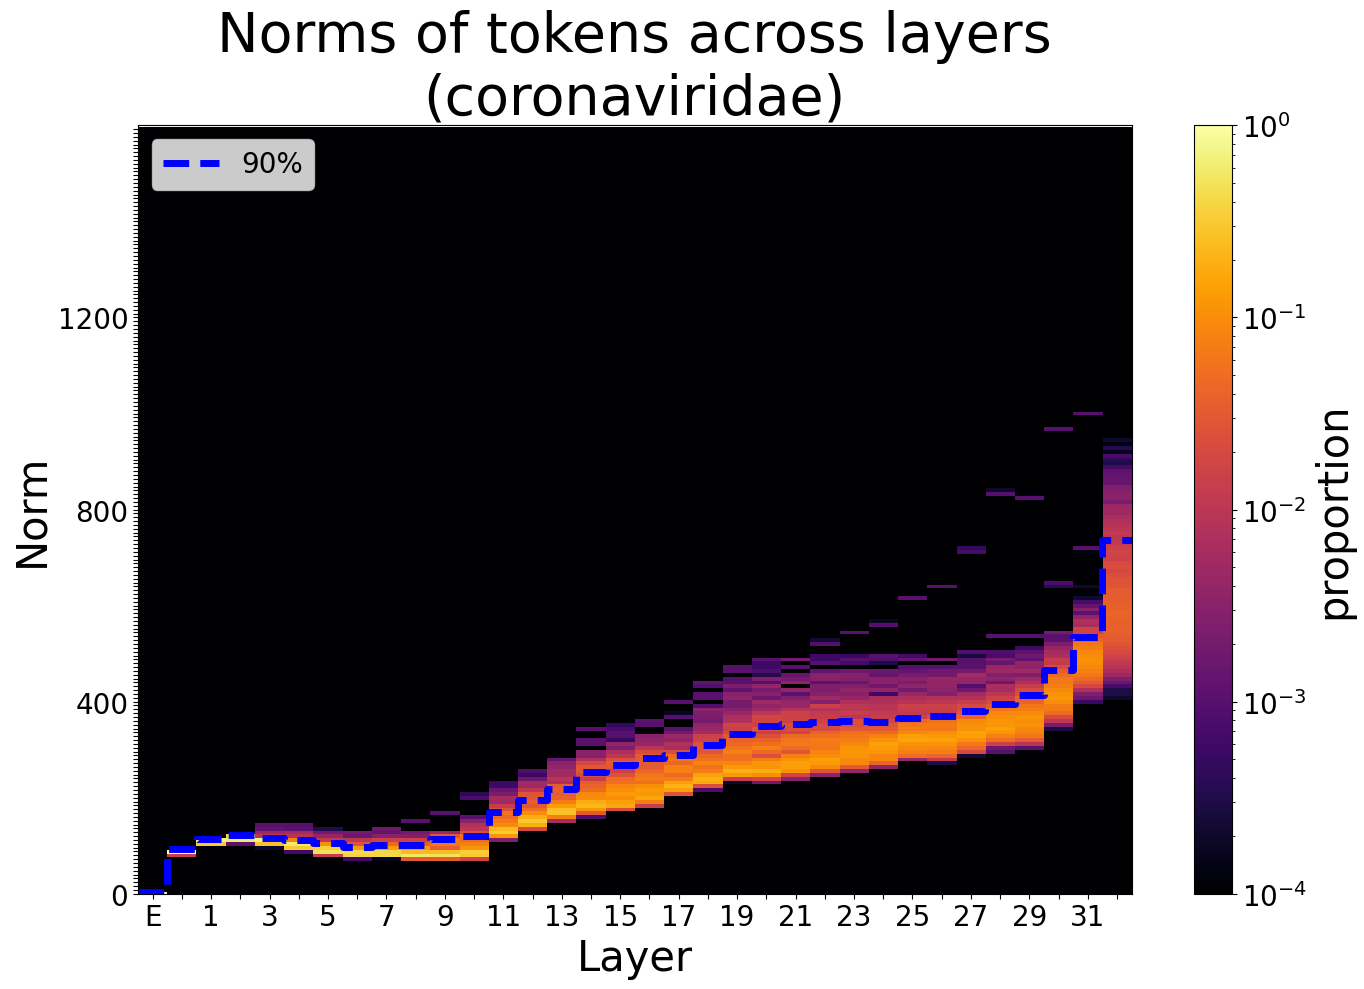

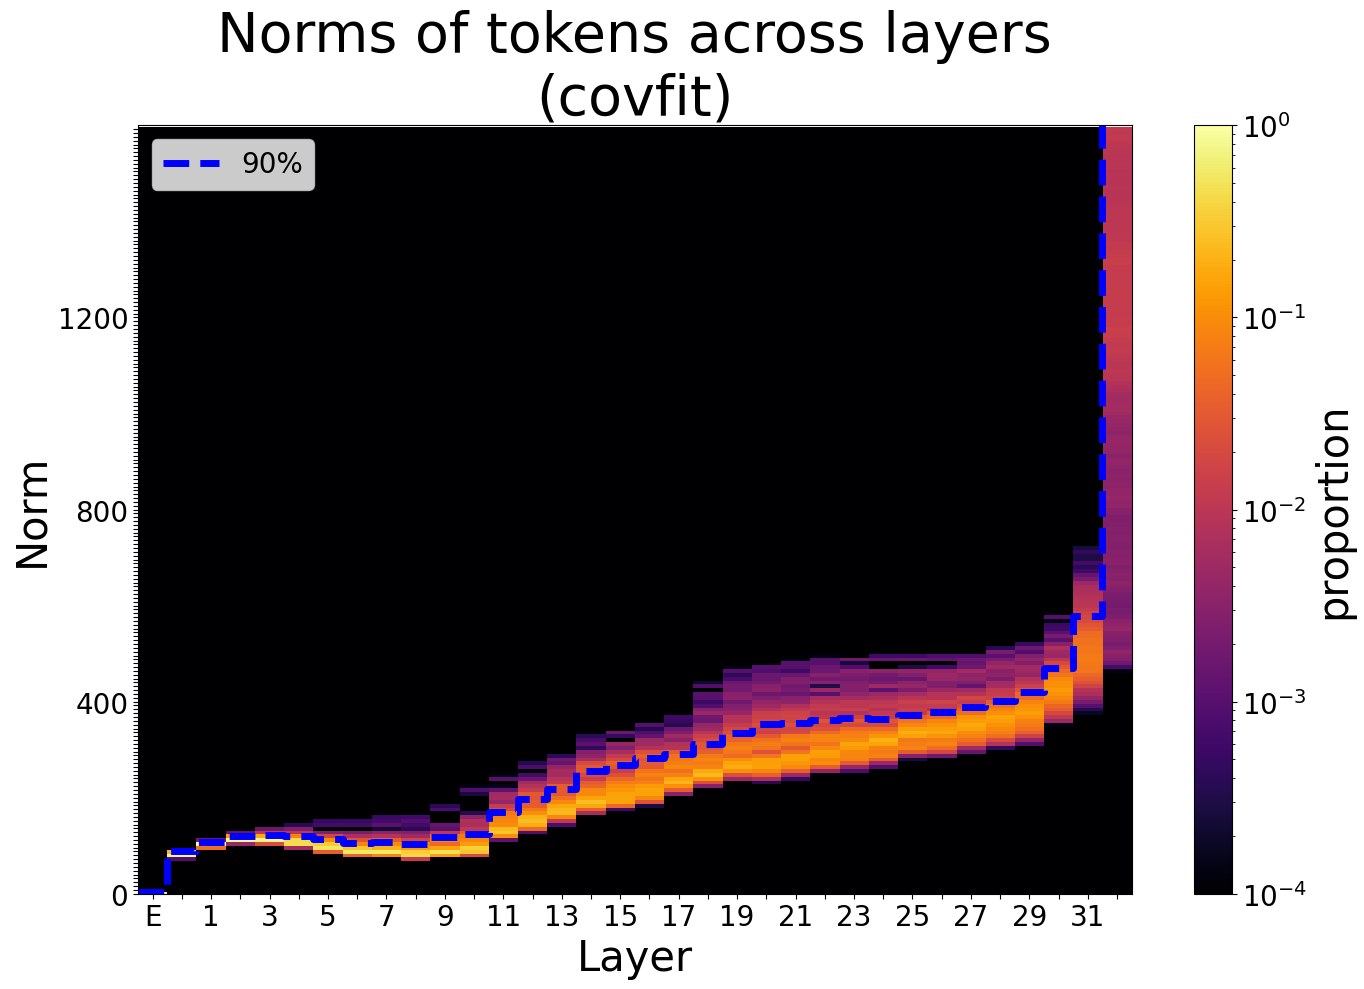

In [119]:
eps = 1e-4
for model_type, density_map, norm_quantiles in zip(["coronaviridae", "covfit"], [density_map_coronaviridae, density_map_covfit], [norm_quantiles_coronaviridae, norm_quantiles_covfit]):
    fig, ax = plt.subplots(1,1,figsize=(14,10))
    ret = ax.imshow(density_map.T + eps, origin='lower', aspect='auto', norm=LogNorm(vmin=eps, vmax=1+eps), cmap="inferno")
    cbar = plt.colorbar(ret)
    cbar.ax.tick_params(labelsize=20)
    cbar.set_label("proportion", fontsize=30)
    ax.set_xticks(torch.arange(hooked_esm.cfg.n_layers+1), ["E", *[x if x % 2 == 1 else "" for x in range(hooked_esm.cfg.n_layers)]], fontsize=20)
    ax.set_yticks(torch.arange(density_map.shape[-1]), [8*x if x % 50 == 0 else "" for x in range(density_map.shape[-1])], fontsize=20)
    ax.set_title(f"Norms of tokens across layers\n({model_type})", fontsize=40)
    ax.set_xlabel("Layer", fontsize=30)
    ax.set_ylabel("Norm", fontsize=30)
    ax.plot([x+r for x in range(hooked_esm.cfg.n_layers + 1) for r in [-0.5,0.5]], [x / 8 for x in norm_quantiles.cpu() for _ in range(2)], linestyle="dashed", color="blue", linewidth=5, label="90%")
    ax.legend(fontsize=20, loc="upper left")
    ax.set_ylim([0,200])
    fig.tight_layout()
    plt.savefig(f"../figures/tok_norm_across_layers_{model_type}.png")
    plt.show()

In [ ]:
def get_high_norm_distr(
    seq_norm,
    quantiles
):
    """
    seq_norm: Tensor[n_layers + 1, num_seq, seq_len]
    quantiles: Tensor[n_layers + 1]
    """

    high_norm_distr = (seq_norm >= quantiles[:, None, None]).view(-1, seq_norm.shape[-1]).to(float).mean(dim=0) #[seq_len]
    return high_norm_distr
high_norm_distr_coronaviridae = get_high_norm_distr(seq_norms_coronaviridae, norm_quantiles_coronaviridae)


In [ ]:
interesting_sites = [*COVARYING_SITE_SETS[0], *COVARYING_SITE_SETS[1]]
topk=20
hot_spots_coronaviridae = np.zeros((hooked_esm.cfg.n_layers + 1, topk))
hot_spots_covfit = np.zeros((hooked_esm.cfg.n_layers + 1, topk))

In [ ]:
print("CORONAVIRIDAE TOP-k TOKEN NORM MEANS FOR EACH LAYER:\n")
for j in range(hooked_esm.cfg.n_layers + 1):
    layer_name = "E" if j == 0 else f"{j - 1} post"
    topk_toks = seq_norms_coronaviridae[j].mean(dim=0).topk(k=topk).indices.cpu().numpy()
    hot_spots_coronaviridae[j,:] = topk_toks
    print(f"%-20s:\t"%layer_name, ",  ".join(["%4s"%(f"{x}") for x in list(topk_toks)]), [x for x in topk_toks if x in interesting_sites])

CORONAVIRIDAE TOP-k TOKEN NORM MEANS FOR EACH LAYER:

E                   :	    0,  1023,   633,   353,   436,   886,   104,    64,   258,   152,   225,   412,   527,   715,   561,   579,    57,   600,   665,   230 []
0 post              :	  426,   463,   479,   412,   665,   225,   230,   384,   251,   491,   631,   217,   499,   209,   507,   600,   589,   272,   728,   295 []
1 post              :	  182,   217,   507,   591,   463,   424,   807,   426,   491,   337,   813,   793,   561,   969,   322,   698,   272,   469,   198,   499 [np.int64(969)]
2 post              :	   13,   343,   165,    14,   331,   424,   426,   616,   809,    61,   122,   280,   556,    17,   507,     9,   969,   282,   603,   217 [np.int64(969)]
3 post              :	   13,    14,    12,     7,     8,     6,     9,     5,    15,    11,    10,     4,     2,   955,     1,     3,   581,   984,   343,    17 []
4 post              :	   13,     8,     7,    14,     6,    12,     5,     9,    10,    11,     4,  

In [ ]:
interesting_sites = [*COVARYING_SITE_SETS[0], *COVARYING_SITE_SETS[1]]
print("COVFIT TOP-k TOKEN NORM MEANS FOR EACH LAYER:\n")
for j in range(hooked_esm.cfg.n_layers + 1):
    layer_name = "E" if j == 0 else f"{j - 1} post"
    topk_toks = seq_norms_covfit[j].mean(dim=0).topk(k=topk).indices.cpu().numpy()
    hot_spots_covfit[j,:] = topk_toks
    print(f"%-20s:\t"%layer_name, ",  ".join(["%4s"%(f"{x}") for x in list(topk_toks)]), [x for x in topk_toks if x in interesting_sites])

COVFIT TOP-k TOKEN NORM MEANS FOR EACH LAYER:

E                   :	    0,  1023,   633,   353,   436,   886,   104,    64,   258,   152,   225,   412,   527,   715,   561,   579,    57,   600,   665,   230 []
0 post              :	  665,   426,   631,   463,   479,   412,   230,   225,   600,   384,   251,   589,   217,   491,   209,   728,   499,   715,   507,   295 []
1 post              :	    9,   807,   728,   217,   463,   426,   862,   174,   715,   897,   561,   507,   793,   631,   337,   579,   863,   812,   986,   295 []
2 post              :	  331,   343,   165,   616,    61,   717,   122,   809,   282,   234,   426,   507,   295,   715,    74,   603,   793,   807,   491,     9 []
3 post              :	   13,     8,     7,   165,    14,   343,    12,    61,     6,     9,   331,     5,   282,   234,   122,   616,   295,    10,   581,    74 []
4 post              :	   13,     8,     7,   984,     6,    10,    12,     9,     5,   955,    14,     4,   165,    61,   956,     2,

In [ ]:
def topk_to_counts(arr):
    arr = arr.astype(np.int32)
    new_arr = np.zeros((arr.shape[0], hooked_esm.cfg.n_ctx))
    for j in range(arr.shape[0]):
        new_arr[j, arr[j]] += 1
    return new_arr
hot_spots_coronaviridae = topk_to_counts(hot_spots_coronaviridae)
hot_spots_covfit = topk_to_counts(hot_spots_covfit)

In [ ]:
# calculating shannon entropy
actual_seqs = rand_seqs
entropies = torch.zeros(actual_seqs.shape[-1])
for aa_idx in range(actual_seqs.shape[-1]):
    aa_vals = actual_seqs[:,aa_idx]
    unique_vals = torch.unique(aa_vals)

    density = (aa_vals[None, :] == unique_vals[:, None]).sum(dim=-1)
    density = density / density.sum()
    entropies[aa_idx] = - (density * density.log()).sum()

In [ ]:
print("P(conserved site):\n", ((entropies == 0).sum() / entropies.shape[0]).item(), "\n")

for name, topk_data in zip(["covfit", "coronaviradae"], [hot_spots_covfit, hot_spots_coronaviridae]):
    l_start = 18
    l_end = 32
    filtered_data = topk_data[l_start:l_end]
    conditional_prob = np.logical_and((filtered_data > 0), (entropies == 0).numpy()).sum() / (filtered_data > 0).sum()

    print(f"({name}) P(conserved site | top-{topk} norm token in any of layers {l_start}-{l_end - 1} inclusive):\n", conditional_prob, "\n")

for name, topk_data in zip(["covfit", "coronaviradae"], [hot_spots_covfit, hot_spots_coronaviridae]):
    aa_start = 900
    aa_end = 1000

    l_start = 19
    l_end = 32
    filtered_data = topk_data[l_start:l_end]
    conditional_prob = (filtered_data > 0)[:,aa_start:aa_end].sum() / (filtered_data > 0).sum()

    print(f"({name}) P(site in range {aa_start}-{aa_end} | top-{topk} norm token in any of layers {l_start}-{l_end - 1} inclusive):\n", conditional_prob, "\n")

P(conserved site):
 0.3603515625 

(covfit) P(conserved site | top-20 norm token in any of layers 18-31 inclusive):
 0.7142857142857143 

(coronaviradae) P(conserved site | top-20 norm token in any of layers 18-31 inclusive):
 0.7357142857142858 

(covfit) P(site in range 900-1000 | top-20 norm token in any of layers 19-31 inclusive):
 0.9192307692307692 

(coronaviradae) P(site in range 900-1000 | top-20 norm token in any of layers 19-31 inclusive):
 0.8884615384615384 



In [ ]:
def plot_norm(
    topk_name_list,
    topk_data_list,
    seq_len,
    xtick_label_data=None,
    save_file=None,
    key_layer_start=18,
    key_layer_end=31
):
    fig,ax = plt.subplots(1,2,figsize=(30,10))
    for i, (topk_name, topk_data) in enumerate(zip(topk_name_list, topk_data_list)):
        # ax[i].hist(topk_data.ravel(), bins=np.linspace(0,hooked_esm.cfg.n_ctx,200))
        ax[i].fill_between(np.arange(seq_len),\
                            y1=topk_data.sum(axis=0),\
                            y2=0,\
                            interpolate=True,\
                            color='blue',\
                            alpha=0.3,\
                            label="High-Norm"\
                           )
        ax[i].set_yticks([])
        ax[i].set_title(topk_name, fontsize=30)
        if xtick_label_data:
            ax[i].set_xticks(xtick_label_data[0], xtick_label_data[1], fontsize=30)
    ax[-1].legend(fontsize=20)
    ax[0].set_ylabel("Density",fontsize=30)
    fig.supxlabel("Site", fontsize=30)
    fig.suptitle(f"Distribution of top-{topk} high-norm tokens across layers", fontsize=40)
    fig.tight_layout()
    if save_file:
        plt.savefig(save_file)
    plt.show()

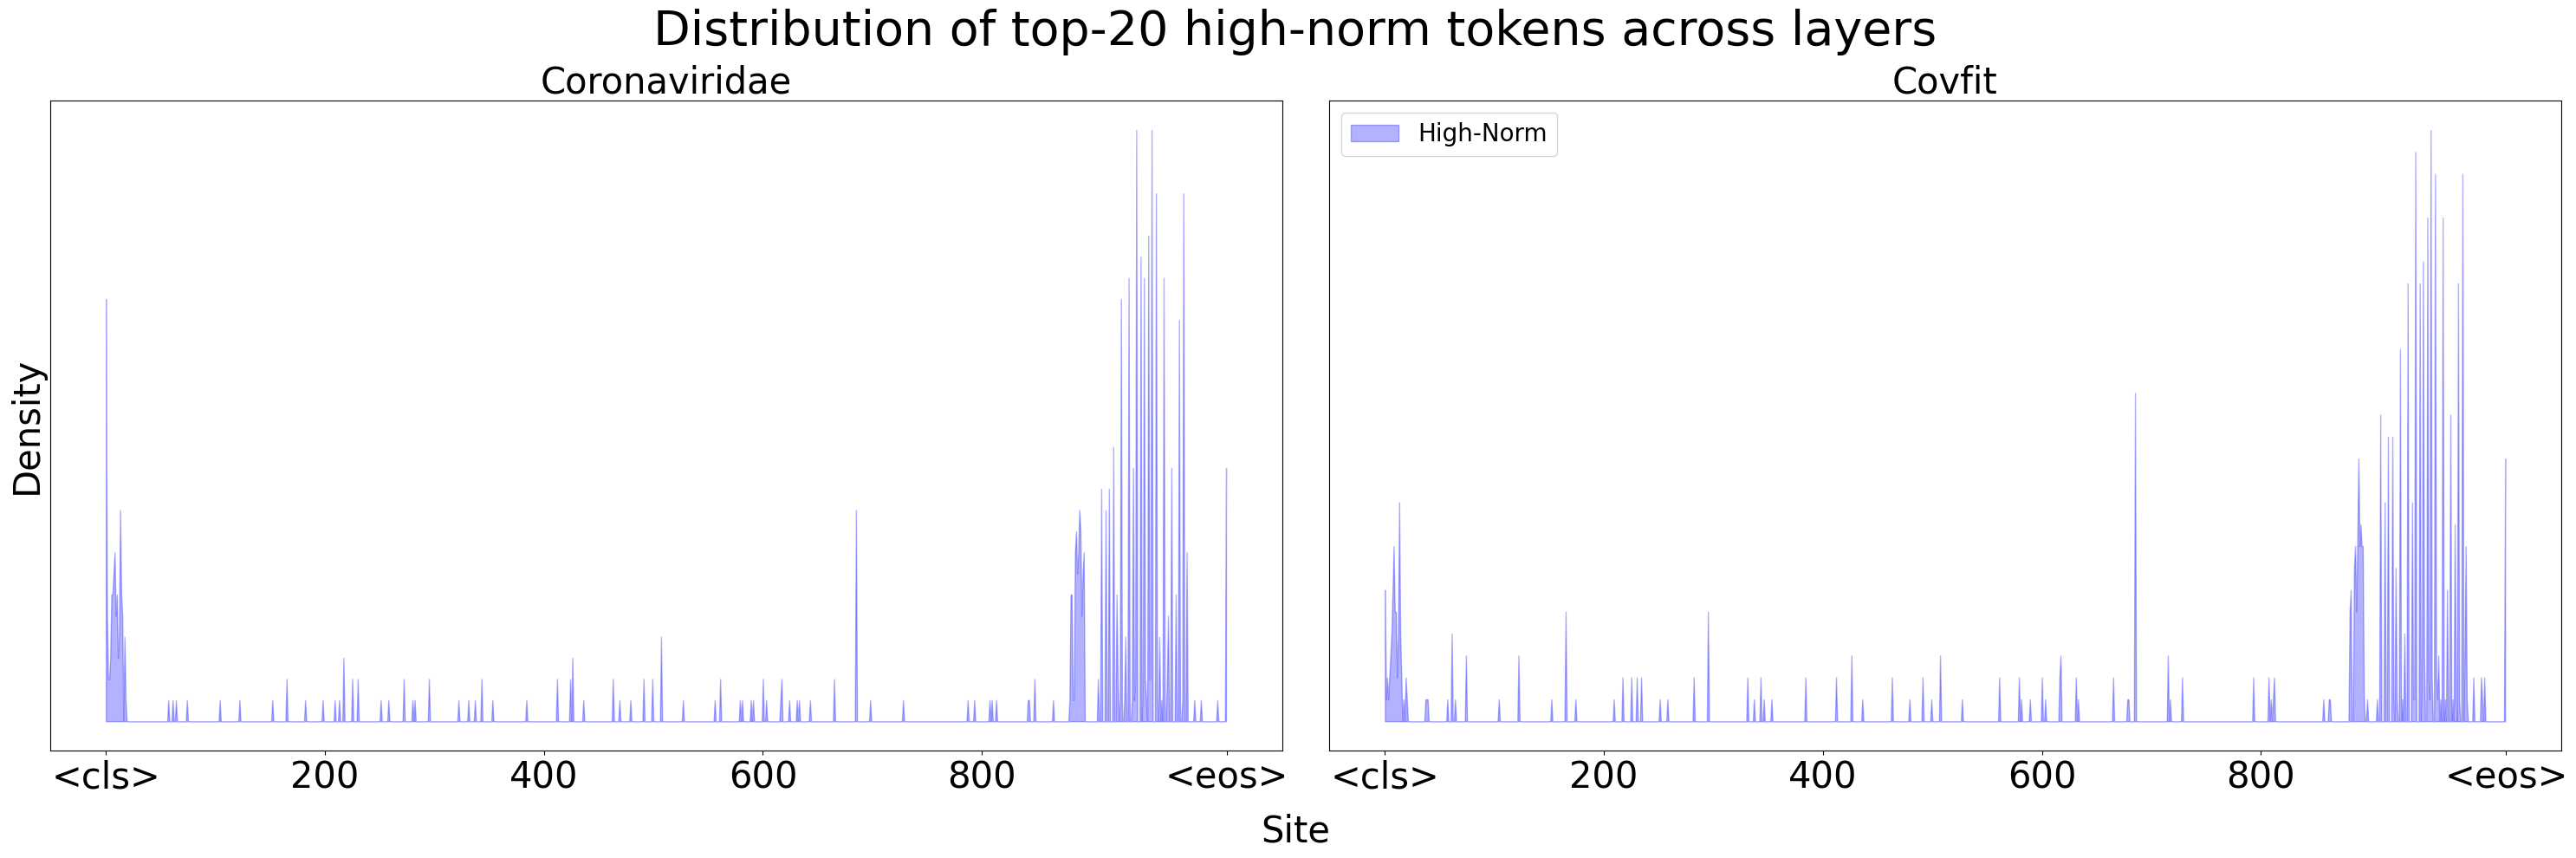

In [ ]:
plot_norm(
    ["Coronaviridae", "Covfit"],
    [hot_spots_coronaviridae, hot_spots_covfit],
    seq_len=hooked_esm.cfg.n_ctx,
    xtick_label_data=[[0,200,400,600,800,hooked_esm.cfg.n_ctx], ["<cls>",200,400,600,800,"<eos>"]],
    save_file=f"../figures/top{topk}_high_norm_tok_distribution.png"
)

### Linear Probe


*   For some fixed layer $\ell$, I cache all tokens $\{tok^{\ell}_{seq,pos}\}_{seq \in D, pos\in [1024]}$ where $D:=$ dataset of sequences and try to reconstruct the original amino acid



In [ ]:
# for training, turn gradients on
torch.autograd.grad_mode.set_grad_enabled(True)

torch.autograd.grad_mode.set_grad_enabled(mode=True)

In [ ]:
torch.manual_seed(0)
rand_idx = torch.randperm(rand_seqs.shape[0])
randperm_seqs = rand_seqs[rand_idx] #random permutation of the sequences

# 60-20-20 split
valid_cutoff = int(0.6 * rand_seqs.shape[0])
test_cutoff = int(0.8 * rand_seqs.shape[0])

train_seqs = randperm_seqs[:valid_cutoff]
valid_seqs = randperm_seqs[valid_cutoff:test_cutoff]
test_seqs = randperm_seqs[test_cutoff:]

In [ ]:
def generate_batch(
    n_batch=10,
    seqs=train_seqs,
    model=hooked_esm,
    fixed_layer = 21,
):
    """
    n_batch: (int) the number of sequences in each batch
    seqs: (Tensor[n_seqs, seq_len]), training sequences
    model: (HookedTransformer)
    fixed_layer: (int) the fixed layer from which to take token embeddings

    returns:
    gt_seqs: (Tensor[seq_len x n_batch]), ground truths where each element is a number from 0-d_vocab
    input_seqs: (Tensor[seq_len x n_batch, d_model]), the token embeddings from layer fixed_layer
    """
    with torch.no_grad():
        idx = torch.randperm(seqs.shape[0])[:n_batch]
        batch_seq = seqs[idx]

        fixed_layer_name = f"blocks.{fixed_layer}.hook_resid_post"
        model_output, cache = model.run_with_cache(batch_seq, names_filter=fixed_layer_name)
        del model_output
        torch.cuda.empty_cache()

    return batch_seq.view(-1), cache[fixed_layer_name].view(-1, model.cfg.d_model)

In [ ]:
class LinearProbe(nn.Module):
    def __init__(
            self,
            input_dim,
            output_dim,
            device=device
    ):
        """
        input_dim = d_model
        output_dim = vocab_length
        """
        super().__init__()
        self.weight = nn.Linear(input_dim, output_dim).to(device)
        self.act = nn.LogSoftmax(dim=-1)

    def forward(self, x):
        return self.act(self.weight(x))

In [ ]:
def generate_eval_batch(
    special_pos,
    seqs,
    model=hooked_esm,
    fixed_layer=25,
):
    """
    special_pos: (Tensor[n]) a subset of [0:seq_len] that specifies important i.e. "special" token positions
                    (such as conserved regions). Token positions not in this list are "regular" token positions
    n_batch: (int) the number of sequences in each batch
    seqs: Tensor[n_seqs, seq_len], training sequences
    model: HookedTransformer
    fixed_layer: (int) the fixed layer from which to take token embeddings

    returns:
    reg_gt_seqs: (Tensor[...]), ground truths for reg_input_seqs
    reg_input_seqs: (Tensor[..., d_model]), the "regular" (see special_pos) token embeddings from layer fixed_layer
    special_gt_seqs: (Tensor[...]), ground truths for special_input_seqs
    special_input_seqs: (Tensor[..., d_model]), the "special" (see special_pos) token embeddings from layer fixed_layer
    """
    with torch.no_grad():
        fixed_layer_name = f"blocks.{fixed_layer}.hook_resid_post"
        model_output, cache = model.run_with_cache(seqs, names_filter=fixed_layer_name)
        fixed_layer_embeddings = cache[fixed_layer_name] # Tensor[batch, seq_len, d_model]
        del model_output
        torch.cuda.empty_cache()

        boolean_special_idx = torch.full(tuple([seqs.shape[1]]), False)
        boolean_special_idx[special_pos] = True

        reg_gt_seqs = seqs[:, torch.logical_not(boolean_special_idx)].view(-1)
        reg_input_seqs = fixed_layer_embeddings[:, torch.logical_not(boolean_special_idx), :].view(-1, model.cfg.d_model)
        special_gt_seqs = seqs[:, boolean_special_idx].view(-1)
        special_input_seqs = fixed_layer_embeddings[:, boolean_special_idx, :].view(-1, model.cfg.d_model)


    return reg_gt_seqs, reg_input_seqs, special_gt_seqs, special_input_seqs

In [ ]:
def eval_register_toks(
    model,
    special_pos_list,
    train_seqs,
    eval_seqs,
    model_name,
    fixed_layer,
    n_batch=10
):
    """
    train a linear probe to reconstrut AA from token embeddings from some fixed layer. Then,
    on some holdout eval_seqs dataset, measure the reconstruction error for "special tokens" vs
    "regular tokens" -- in our case "special tokens" are high-norm tokens

    model: (HookedTransformer)
    special_pos_list: (Array-like) list of special sites to evaluate as register tokens
    generate_train_batch: (Callable) function that generates a tuple (ground truth, input) for training given a fixed layer
    generate_eval_batch: (Callable) function that generates a tuple (ground truth, input) for eval and takes
                        as input special_pos, batched_seqs, and some fixed layer and generates
                        (regular ground truth, regular input, special ground truth, special input)
    eval_seqs: (Tensor[n_seqs, d_model]) sequences for evaluating
    model_name (str) name of model for training loss figures
    fixed_layer: (int) the fixed layer from which to take token embeddings
    """
    linear_probe = LinearProbe(model.cfg.d_model, model.cfg.d_vocab).to(device)
    loss_func = nn.NLLLoss(reduction="mean")
    optimizer = torch.optim.Adam(linear_probe.parameters(), lr=0.001)

    # train Linear Probe
    losses = []
    n_epochs = 500
    for epoch in tqdm(range(n_epochs)):
        tok_gt, tok_embeds = generate_batch(n_batch=n_batch, seqs=train_seqs, model=model, fixed_layer=fixed_layer)
        tok_pred = linear_probe(tok_embeds)
        loss = loss_func(tok_pred, tok_gt)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        losses.append(loss.item())

    del tok_gt
    del tok_embeds
    del tok_pred
    torch.cuda.empty_cache()

    fix, ax = plt.subplots(1,1,figsize=(5,5))
    ax.set_title(f"({model_name}) loss over epochs")
    ax.set_ylabel("loss")
    ax.set_xlabel("epochs")
    ax.plot(np.arange(len(losses)), losses)
    plt.show()

    # Evaluate loss and test whether conserved sites have lower reconstruction loss
    eval_loss_func = nn.NLLLoss(reduction="sum")
    eval_seqs = valid_seqs

    reg_loss = 0
    special_loss = 0
    eval_batch_size = 10
    with torch.no_grad():
        for batched_eval_idx in tqdm(range(0,eval_seqs.shape[0],eval_batch_size)):
            batched_seqs = eval_seqs[batched_eval_idx:batched_eval_idx+eval_batch_size]

            reg_gt_seqs, reg_input_seqs, special_gt_seqs, special_input_seqs = generate_eval_batch(
                special_pos_list,
                seqs=batched_seqs,
                fixed_layer=21,
                model=model
            )

            reg_tok_pred = linear_probe(reg_input_seqs)
            special_tok_pred = linear_probe(special_input_seqs)

            reg_loss += eval_loss_func(reg_tok_pred, reg_gt_seqs)
            special_loss += eval_loss_func(special_tok_pred, special_gt_seqs)

    # num_special_toks x num_seqs
    total_special_tokens = (special_pos_list.shape[0]) * eval_seqs.shape[0]

    # (seq_len - num_special_toks) x num_seqs
    total_reg_tokens = (eval_seqs.shape[1] - special_pos_list.shape[0]) * eval_seqs.shape[0]

    mean_special_loss = special_loss / total_special_tokens
    mean_reg_loss = reg_loss / total_reg_tokens


    print(f"{model_name}\nRegular token loss: {mean_reg_loss}\nOutlier token loss: {mean_special_loss}")

In [ ]:
special_pos_l25 = torch.tensor([0,959,952,1023,945,984,941,966,920,955,948,934,927,\
                            973,913,980,938,916,685,909,977,987,970,923,962,931,\
                            889,956,924,963,917,890,949,892,888,942,991,893,969,\
                            988,930,994,887,983,981,944,937,902,910,896]).to(device)
special_pos_l21 = torch.tensor([0,959,952,945,941,920,934,984,966,927,955,913,948,\
                            916,923,938,973,980,931,924,909,917,987,889,1023,890,\
                            888,893,991,962,887,949,892,886,930,891,963,983,977,\
                            956,944,942,900,905,906,910,896,685,885,935])

In [ ]:
# eval registor toks for covfit
fixed_layer = 21
eval_register_toks(
    hooked_esm_covfit,
    special_pos_l21,
    train_seqs=train_seqs,
    eval_seqs=valid_seqs,
    model_name="covfit",
    fixed_layer=21,
    n_batch=10
)

In [ ]:
# eval registor toks for covfit
fixed_layer = 21
eval_register_toks(
    hooked_esm,
    special_pos_l21,
    train_seqs=train_seqs,
    eval_seqs=valid_seqs,
    model_name="coronaviridae",
    fixed_layer=21,
    n_batch=10
)

## Attention Sinks

Given a fixed attention head in a fixed layer, a token position $j$ is an "attention sink" if:

$\displaystyle\left(\frac{1}{n}\sum_{i=1}^n\chi_{\{\alpha_{ij}\geq \tau\}}\right)\geq \gamma$

where $i$ ranges over a large $n$ number of source tokens, $\alpha_{ij}$ is the attention weight that source token $i$ gives to position $j$ token, $\tau$ represents the 90th percentile of attention weights (taken wrt the attention head and layer of $\alpha_{ij}$ on the source token), and $\gamma$ is some fixed threshold in $(0,1)$;
we take $\gamma$ to be $0.4$.

In [35]:
def get_p_layer_p_attn_percentile(
    model,
    seqs,
    key_layer_start,
    key_layer_end,
    percentile=0.9,
    n_batch=10,
):
    n_seqs = seqs.shape[0]
    p_layer_p_attn_percentiles = torch.zeros(model.cfg.n_layers, model.cfg.n_heads, model.cfg.n_ctx).to(device)

    for batch_idx in tqdm(range(0,n_seqs,n_batch)):
        batch_seq = seqs[batch_idx:batch_idx + n_batch]
        _, cache = model.run_with_cache(batch_seq, names_filter=lambda x: "pattern" in x)
        for layer in range(key_layer_start, key_layer_end, 1):
            attn_patterns = cache[f"blocks.{layer}.attn.hook_pattern"] # [batch, n_heads, n_ctx, n_ctx]
            reshaped_attn = torch.transpose_copy(attn_patterns, 0, 1).to(device) # [n_heads, batch, n_ctx, n_ctx]
            quantiles = torch.quantile(reshaped_attn.view(model.cfg.n_heads, -1), 0.9, dim=-1) #[n_heads]
            sink_scores = (reshaped_attn >= quantiles[:,None,None,None]).sum(dim=1, keepdim=True).sum(dim=2, keepdim=True).squeeze() #[n_heads, n_ctx]

            # sum over batch and rows
            p_layer_p_attn_percentiles[layer] += sink_scores
            del reshaped_attn
        del _
        del cache
        torch.cuda.empty_cache()

    p_layer_p_attn_percentiles = p_layer_p_attn_percentiles / (n_seqs * model.cfg.n_ctx)
    return p_layer_p_attn_percentiles[key_layer_start:key_layer_end]

In [22]:
p_layer_p_attn_percentiles = get_p_layer_p_attn_percentile(
    hooked_esm,
    seqs=rand_seqs,
    key_layer_start=18,
    key_layer_end=32
)

100%|██████████| 462/462 [06:34<00:00,  1.17it/s]


In [44]:
# is_attn_sink = (p_layer_p_attn_percentiles >= 0.3).to(float)
cum_attn_sink_score = p_layer_p_attn_percentiles.view(-1,CONTEXT_LEN).mean(dim=0)

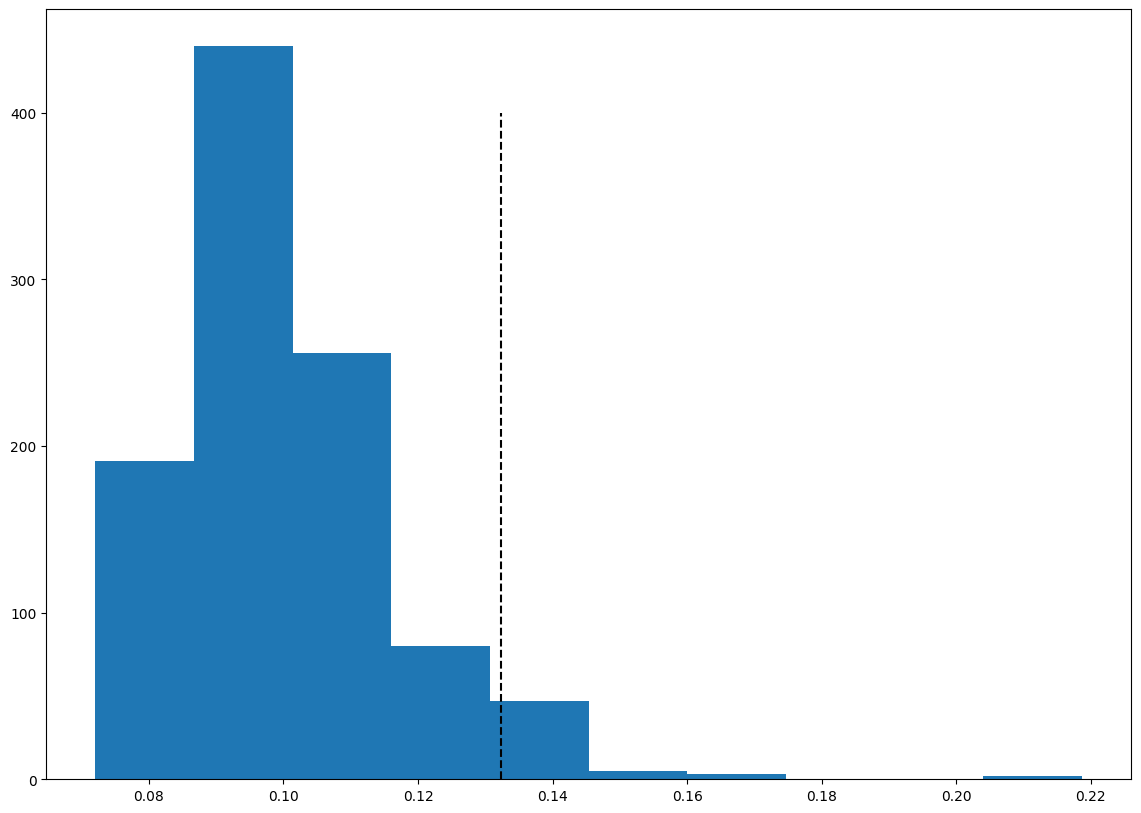

In [51]:
thresh = torch.quantile(cum_attn_sink_score, 0.95)
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.hist(cum_attn_sink_score.cpu())
ax.plot([thresh.cpu() for _ in range(2)],[0,400],linestyle="dashed", color="black")
plt.show()

In [ ]:
def get_mean_attn(
    model,
    seqs,
    n_batch=10,
    device=device
):
    layer_pattern = torch.zeros(model.cfg.n_layers, model.cfg.n_heads, model.cfg.n_ctx, model.cfg.n_ctx).to(device)
    print(layer_pattern.shape)
    n_seqs = seqs.shape[0]

    for batch_idx in tqdm(range(0,n_seqs,n_batch)):
        batch_seqs = seqs[batch_idx:batch_idx + n_batch]
        _, cache = model.run_with_cache(batch_seqs, names_filter=lambda x: "pattern" in x)

        for layer in range(model.cfg.n_layers):
            layer_pattern[layer] += cache[f"blocks.{layer}.attn.hook_pattern"].sum(axis=0)

        del _
        del cache
        torch.cuda.empty_cache()
    return layer_pattern / n_seqs


In [ ]:
layer_pattern_covfit = get_mean_attn(hooked_esm_covfit, seqs=rand_seqs)

torch.Size([33, 20, 1024, 1024])


100%|██████████| 462/462 [06:11<00:00,  1.24it/s]


In [ ]:
layer_pattern_coronaviridae = get_mean_attn(hooked_esm, seqs=rand_seqs)

torch.Size([33, 20, 1024, 1024])


100%|██████████| 462/462 [06:11<00:00,  1.24it/s]


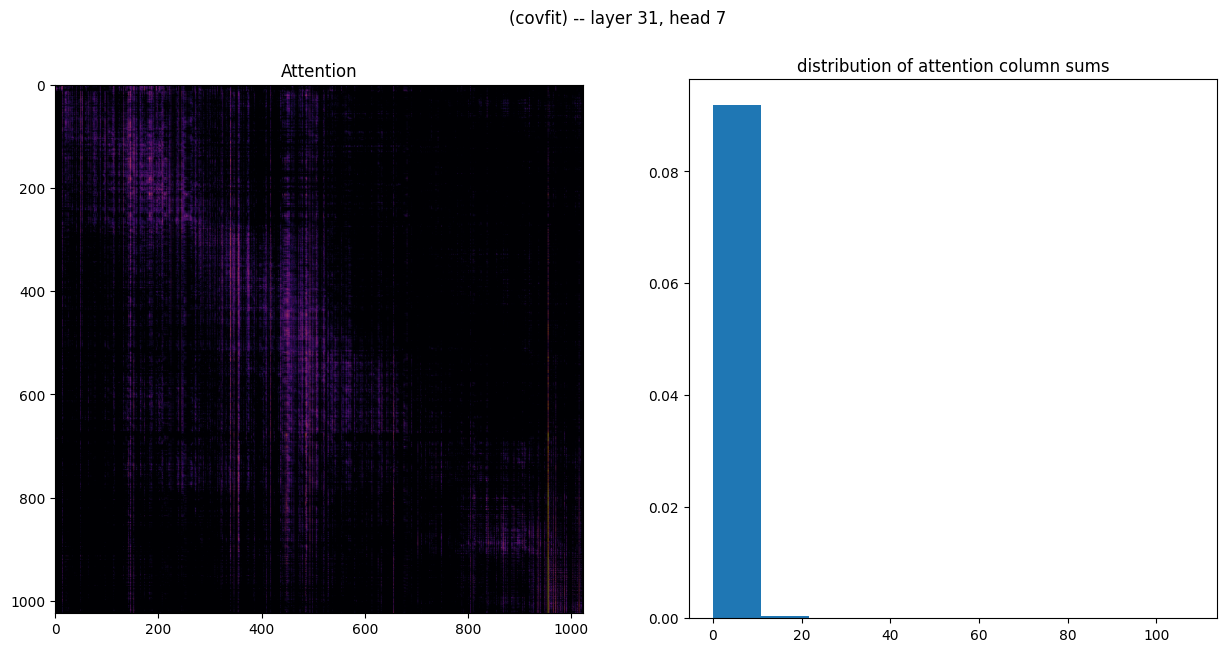

torch.return_types.topk(
values=tensor([108.3269,  15.6437,  15.1936,  12.6465,  11.5231,   9.8979,   8.0286,
          7.6685,   7.1314,   6.6344], device='cuda:0'),
indices=tensor([ 954, 1023,  339,  354,  493,  486,  146,    0,  450,  417],
       device='cuda:0'))


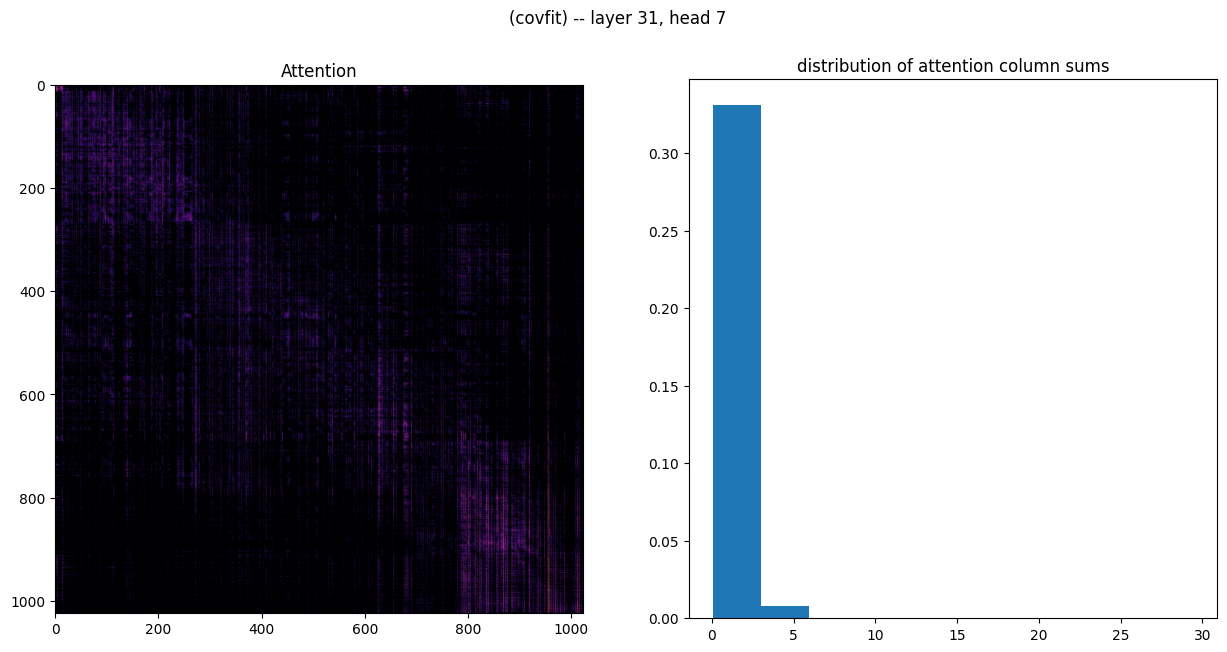

torch.return_types.topk(
values=tensor([29.4530, 18.8704, 13.3173,  6.8814,  5.9126,  4.8023,  4.5944,  4.5179,
         4.4029,  4.2112], device='cuda:0'),
indices=tensor([ 954,    0, 1023,  868,  918,  628,  957,  875, 1014,  625],
       device='cuda:0'))


In [ ]:
def plot_agg_attn(layer_pattern, layer, head, name):
    fig,ax = plt.subplots(1,2,figsize=(15,7))
    ax[0].imshow(layer_pattern[layer,head].cpu(), norm=LogNorm(vmin=1e-3, vmax=1), cmap="inferno")
    ax[1].hist(layer_pattern[layer, head].sum(dim=0).cpu(), density=True)
    fig.suptitle(f"({name}) -- layer {layer}, head {head}")
    ax[0].set_title("Attention")
    ax[1].set_title("distribution of attention column sums")
    plt.show()
    print(layer_pattern[layer,head].sum(dim=0).topk(k=10))

layer = 31
head = 7
plot_agg_attn(layer_pattern_covfit, layer=layer, head=head, name="covfit")
plot_agg_attn(layer_pattern_coronaviridae, layer=layer, head=head, name="covfit")

In [ ]:
key_layer_start = 18
key_layer_end = 32

In [ ]:
def aggregate_attn(layer_pattern, key_layer_start, key_layer_end):
    return layer_pattern[key_layer_start:key_layer_end].sum(dim=-2).mean(dim=0).mean(dim=0)

# take mean of attention row sums over key layers over all head
agg_attn_pattern_coronaviridae = aggregate_attn(layer_pattern_coronaviridae, key_layer_start, key_layer_end)
agg_attn_pattern_covfit = aggregate_attn(layer_pattern_covfit, key_layer_start, key_layer_end)

In [ ]:
def plot_attn_vs_norm(
    topk_name_list,
    topk_data_list,
    attn_data_list,
    seq_len,
    xtick_label_data=None,
    idx=None,
    bbox_to_anchor=None,
    key_layer_start=key_layer_start,
    key_layer_end=key_layer_end,
    save_file=None
):
    bbox_to_anchor=(0.29, 0.9) if bbox_to_anchor is None else bbox_to_anchor
    fig,ax = plt.subplots(1,2,figsize=(20,10))
    idx = torch.arange(seq_len) if idx is None else idx
    for i, (topk_name, topk_data, attn_data) in enumerate(zip(topk_name_list, topk_data_list, attn_data_list)):
        ax[i].fill_between(np.arange(seq_len)[idx],\
                        y1=topk_data[key_layer_start:key_layer_end].sum(axis=0)[idx],\
                        y2=0,\
                        interpolate=True,\
                        color='blue',
                        label="High-Norm",\
                        alpha=0.3)
        ax[i].tick_params(axis='y', labelcolor="blue")
        axi2 = ax[i].twinx()
        axi2.fill_between(np.arange(seq_len)[idx],\
                        y1=attn_data.cpu()[idx],\
                        y2=0,\
                        interpolate=True,\
                        color='red',\
                        label="Agg. Attn",\
                        alpha=0.5)
        axi2.tick_params(axis='y', labelcolor="red")
        if xtick_label_data:
            ax[i].set_xticks(xtick_label_data[0], xtick_label_data[1], fontsize=30)
        ax[i].set_yticks(np.arange(0,14,2),np.arange(0,14,2),fontsize=20)
        axi2.set_yticks(np.arange(0,14,2),np.arange(0,14,2),fontsize=20)
        ax[i].set_title(topk_name, fontsize=30)
    ax[-1].legend(fontsize=20, loc="upper left")
    axi2.legend(fontsize=20, bbox_to_anchor=bbox_to_anchor)
    # ax[0].set_ylabel("Density",fontsize=30)
    fig.supxlabel("Site", fontsize=30)
    fig.suptitle(f"Distribution of top-{topk} High-Norm vs. High-Attn. tokens (layers {key_layer_start} - {key_layer_end - 1})", fontsize=40)
    fig.tight_layout()
    if save_file:
        plt.savefig(save_file)
    plt.show()

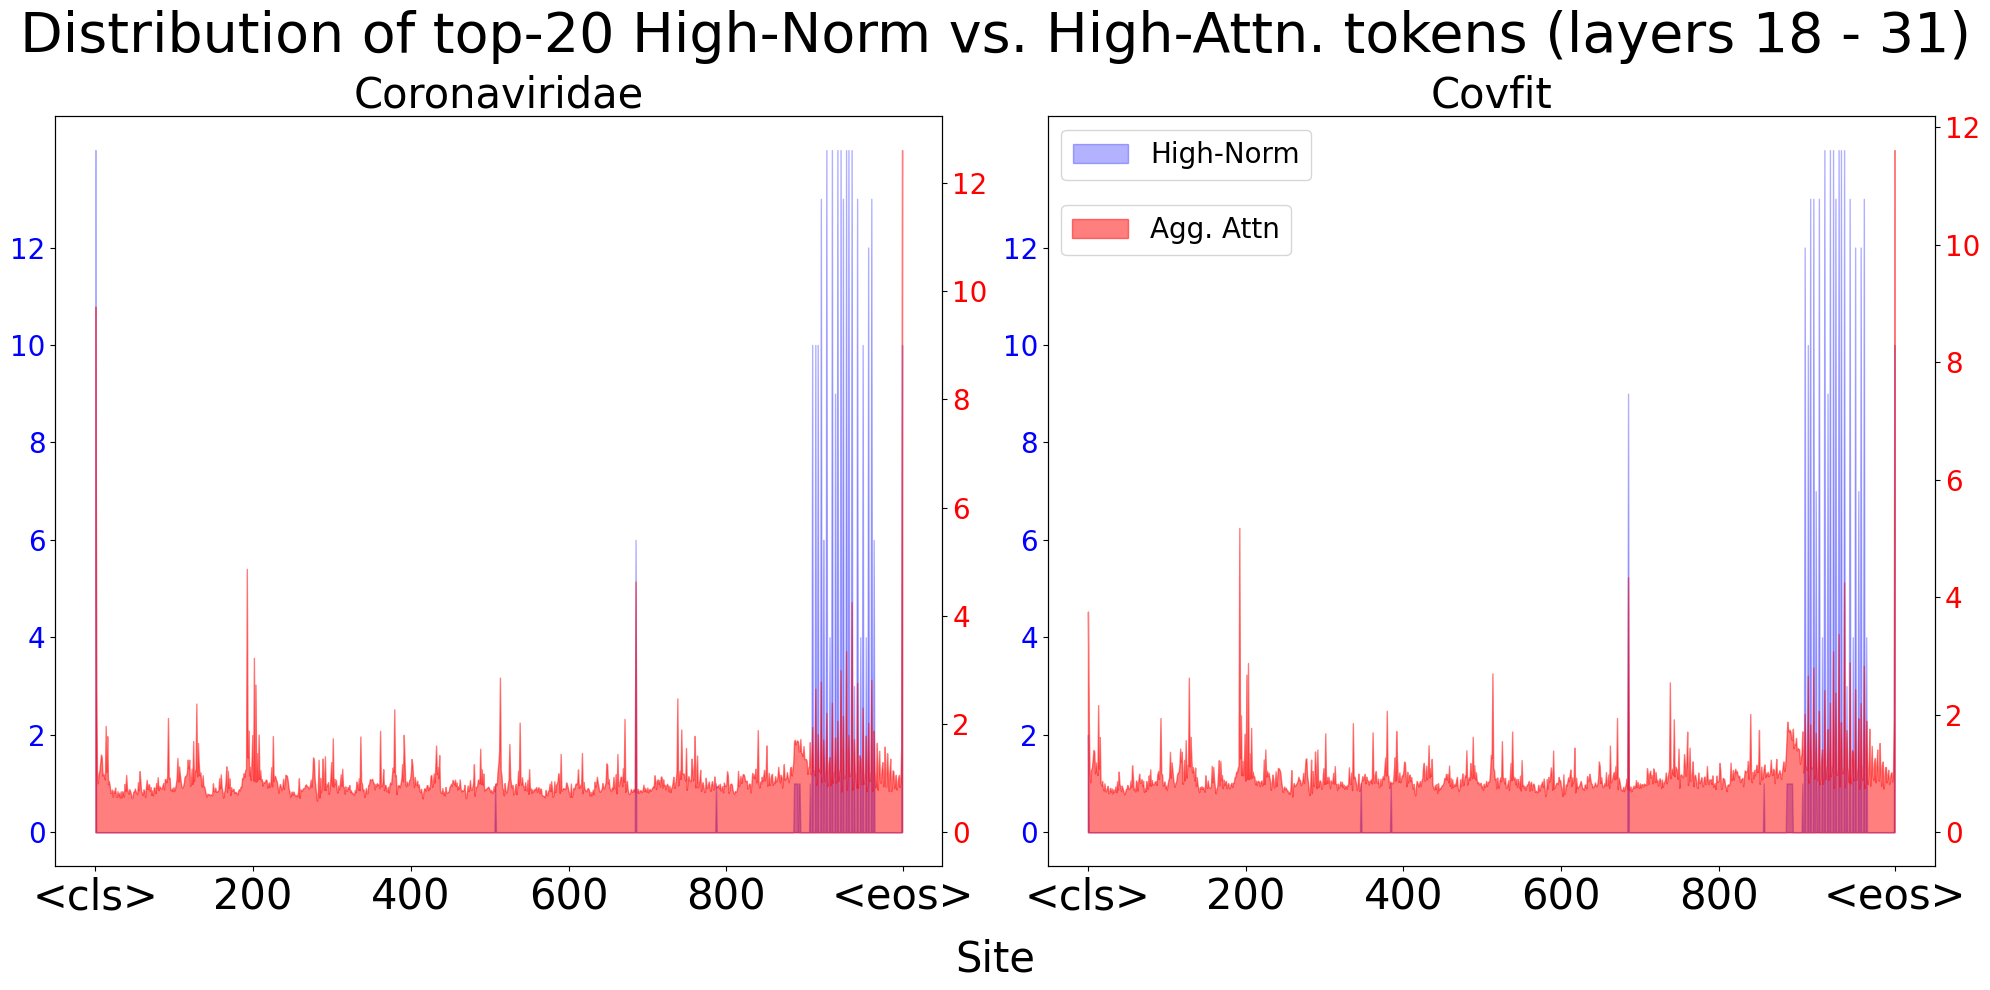

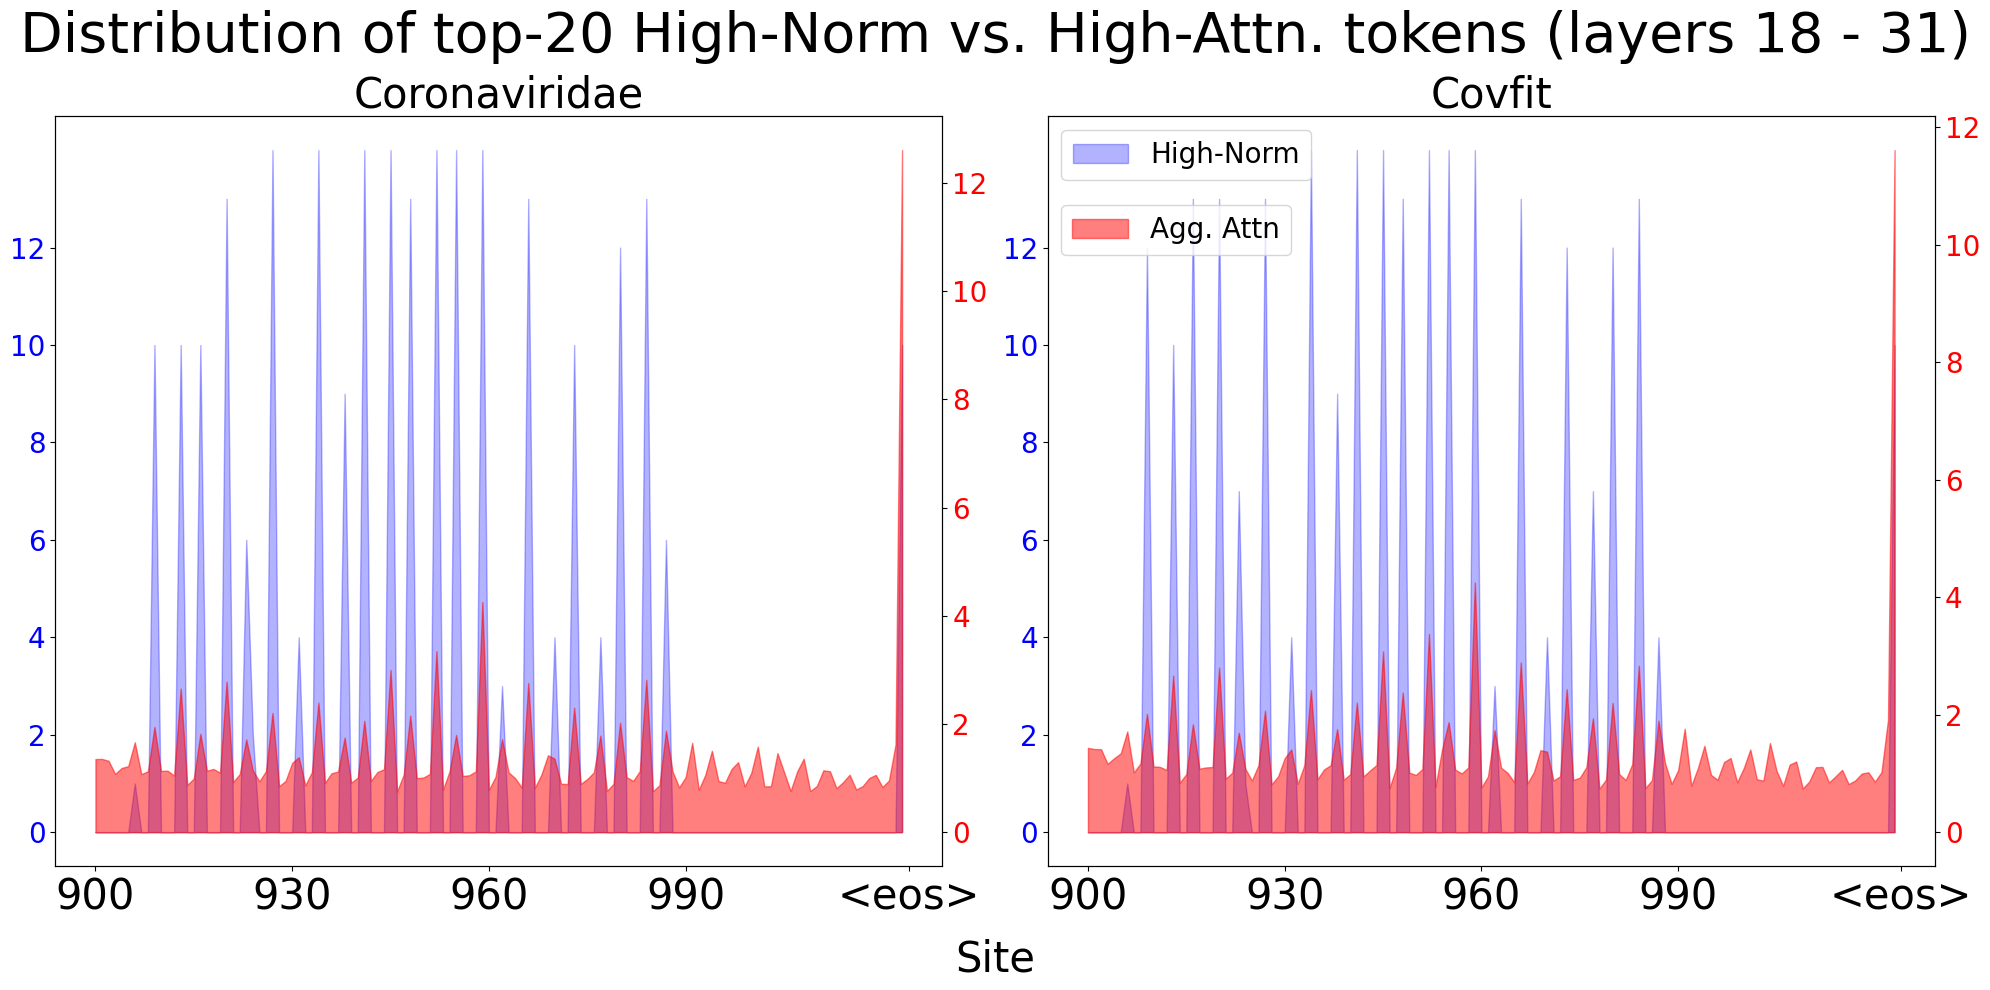

In [ ]:
plot_attn_vs_norm(
    topk_name_list=["Coronaviridae", "Covfit"],
    topk_data_list=[hot_spots_coronaviridae, hot_spots_covfit],
    attn_data_list=[agg_attn_pattern_coronaviridae, agg_attn_pattern_covfit],
    seq_len=hooked_esm.cfg.n_ctx,
    xtick_label_data=[[0,200,400,600,800,hooked_esm.cfg.n_ctx], ["<cls>",200,400,600,800,"<eos>"]],
    bbox_to_anchor=(0.29,0.9),
    save_file="../figures/norm_vs_attn.png"
)

plot_attn_vs_norm(
    topk_name_list=["Coronaviridae", "Covfit"],
    topk_data_list=[hot_spots_coronaviridae, hot_spots_covfit],
    attn_data_list=[agg_attn_pattern_coronaviridae, agg_attn_pattern_covfit],
    seq_len=hooked_esm.cfg.n_ctx,
    idx=torch.arange(900,hooked_esm.cfg.n_ctx),
    xtick_label_data=[[900,930,960,990,hooked_esm.cfg.n_ctx], [900,930,960,990,"<eos>"]],
    bbox_to_anchor=(0.29,0.9),
    save_file="../figures/norm_vs_attn_zoomed.png"
)

In [ ]:
def plot_attn_norm_joint(
    topk_name_list,
    topk_data_list,
    attn_data_list,
    seq_len,
    key_layer_start=key_layer_start,
    key_layer_end=key_layer_end,
):
    for i, (name, topk_data, attn_data) in enumerate(zip(topk_name_list, topk_data_list, attn_data_list)):
        # on average, a high-norm
        topk_data_density = topk_data[key_layer_start+1:key_layer_end+1].mean(axis=0)

        # on average, across all layers, heads, and tokens, these tokens are consistently attended to
        attn_data_density = attn_data[key_layer_start:key_layer_end].view(-1, seq_len)
        attn_data_density = attn_data_density.mean(dim=0).cpu().numpy()

        interesting_idx = np.logical_and(
            topk_data_density > np.quantile(topk_data_density, 0.98),
            attn_data_density > np.quantile(attn_data_density, 0.98),
        )
        tok_names = ["<cls>", *list(range(1,seq_len-1)), "<eos>"]
        interesting_toks = [tok_names[i] if interesting_idx[i] else "low-norm/low-attn" for i in range(seq_len)]

        plotting_df = pd.DataFrame({"attn": attn_data_density, "norm":topk_data_density, "label":interesting_toks})
        fig = px.scatter(
            plotting_df,
            x="attn",
            y="norm",
            color="label",
            marginal_x="histogram",
            marginal_y="histogram",
            title=f"top-{topk} norm vs. high attn. joint plot"
        )
        fig.show()
        fig.write_image(f"../figures/{name}_top{topk}norm_vs_attn_joint.png")


plot_attn_norm_joint(
    topk_name_list=["Coronaviridae", "Covfit"],
    topk_data_list=[hot_spots_coronaviridae, hot_spots_covfit],
    attn_data_list=[layer_pattern_coronaviridae, layer_pattern_covfit],
    seq_len=hooked_esm.cfg.n_ctx,
)

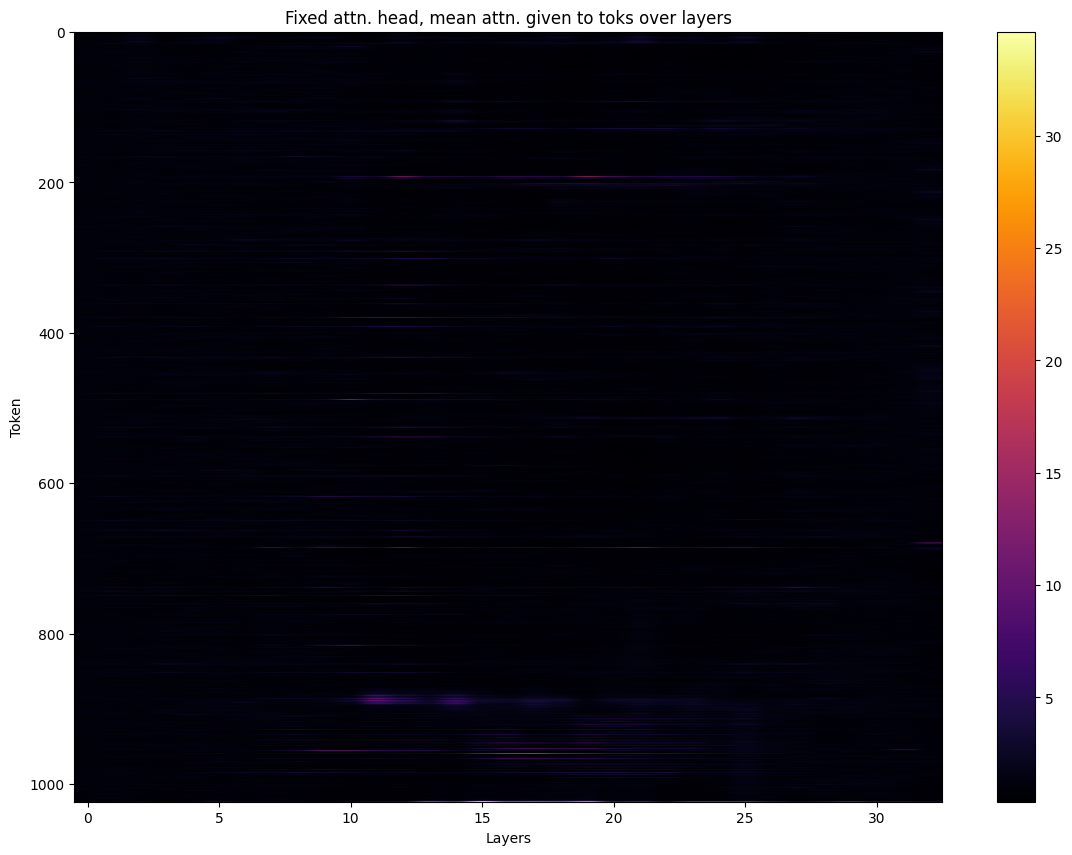

In [ ]:
# visualizing attention scores
head = 4
fig, ax = plt.subplots(1,1,figsize=(14,10))
# ret = ax.imshow(layer_head_attn.cpu(), norm=LogNorm(vmin=1e-3, vmax=1), cmap="inferno")
ax.set_title("Fixed attn. head, mean attn. given to toks over layers")
# ret = ax.imshow(layer_pattern[:,head].sum(dim=1).cpu().T, aspect='auto', cmap="inferno")
ret = ax.imshow(layer_pattern_covfit.mean(dim=1).sum(dim=1).cpu().T, aspect='auto', cmap="inferno")
ax.set_xlabel("Layers")
ax.set_ylabel("Token")
plt.colorbar(ret)
plt.show()

## Ablate high-norm tokens and measure effect via perplexity

In [ ]:
fixed_layer=21
key_layer_start = 18
key_layer_end = 32
topk=20

In [ ]:
topk_distr = hot_spots_covfit[key_layer_start:key_layer_end].sum(axis=0)
special_pos_list = np.where(topk_distr > np.quantile(topk_distr, 0.97))[0]

In [ ]:
def mean_ablate_high_norm_toks(
    res_vector: Float[Tensor, "batch pos d_model"],
    hook: HookPoint,
    special_pos, # Tensor of shape which is subset of batch
):
    res_vector[:, special_pos, :] = res_vector.mean(dim=0, keepdim=True)[:, special_pos, :]
    return res_vector

In [ ]:
def mean_ablate_conserved_toks(
    model,
    get_logit_hooked,
    seqs: Float[Tensor, "batch seq_len"],
    fixed_layer,
    special_pos_list,
    n_batch=40,
):
    print(special_pos_list)
    for batch_idx in tqdm(range(0,seqs.shape[0], n_batch)):
        batch_seq = seqs[batch_idx:batch_idx+n_batch]
        model.reset_hooks()

        reg_output = get_logit_hooked(model(batch_seq)) # [batch, seq_len, d_output]
        reg_output_vals = torch.gather(reg_output, dim=-1, index=batch_seq[:,:,None]).squeeze() #[batch, seq_len] corresponding to gt AA
        model.add_hook(
            utils.get_act_name("resid_post", fixed_layer),
            functools.partial(mean_ablate_high_norm_toks, special_pos=special_pos_list),
            dir="fwd"
        )
        ablated_output = get_logit_hooked(model(batch_seq)) # [batch, seq_len, d_output]
        ablated_output_vals = torch.gather(ablated_output, dim=-1, index=batch_seq[:,:,None]).squeeze() #[batch, seq_len] corresponding to gt AA
        diff = (reg_output_vals - ablated_output_vals).abs().mean(dim=0)
    model.reset_hooks()
    return diff

In [ ]:
logit_diffs = mean_ablate_conserved_toks(
    hooked_esm,
    get_logit_hooked=get_logit_coronaviridae,
    seqs=rand_seqs,
    fixed_layer=fixed_layer,
    special_pos_list=torch.tensor(special_pos_list).to(device)
)
torch.cuda.empty_cache()

tensor([   0,  685,  909,  913,  916,  920,  923,  927,  931,  934,  938,  941,
         945,  948,  952,  955,  959,  962,  966,  970,  973,  977,  980,  984,
         987, 1023], device='cuda:0')


100%|██████████| 116/116 [06:49<00:00,  3.53s/it]


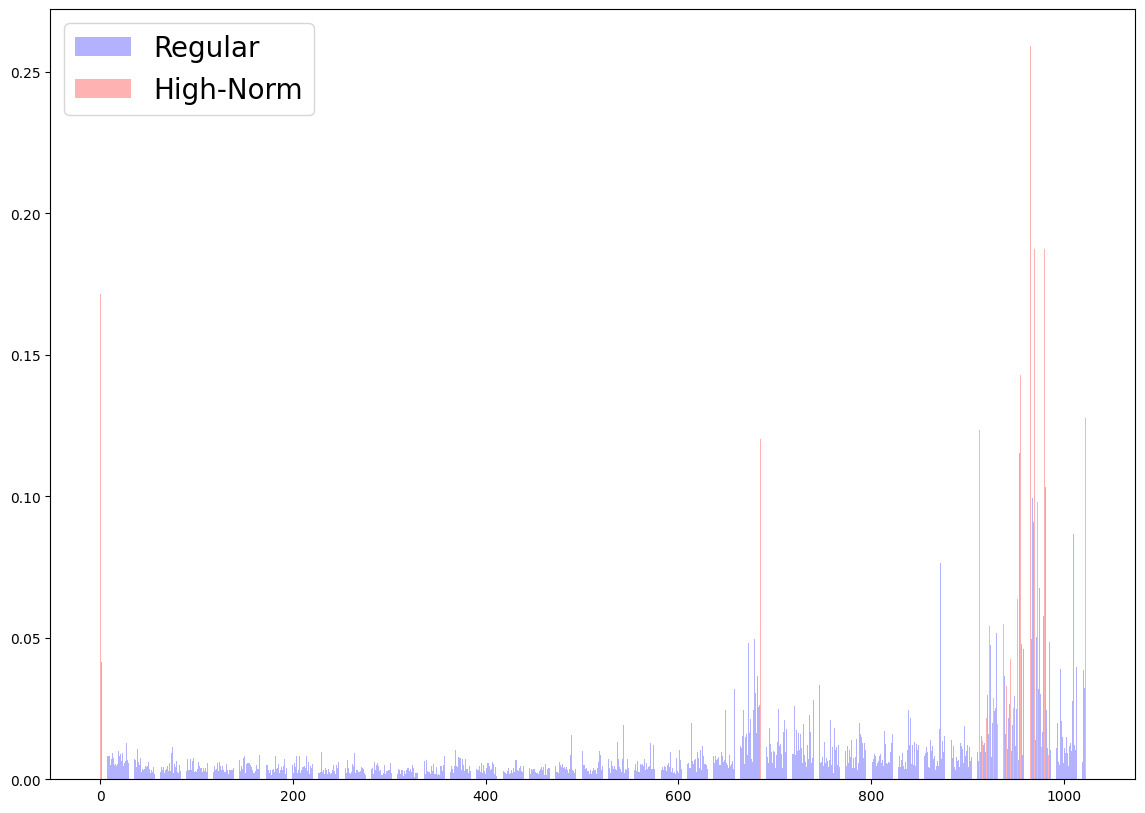

In [ ]:
idx = torch.full(tuple([hooked_esm.cfg.n_ctx]), True)
idx[special_pos_list] = False

fig,ax = plt.subplots(1,1,figsize=(14,10))
ax.bar(np.arange(hooked_esm.cfg.n_ctx)[idx],\
                height=logit_diffs.cpu()[idx],\
                color='blue',\
                alpha=0.3,\
                label="Regular"
                )
ax.bar(np.arange(hooked_esm.cfg.n_ctx)[torch.logical_not(idx)],\
                height=logit_diffs.cpu()[torch.logical_not(idx)],\
                color='red',\
                alpha=0.3,\
                label="High-Norm"
                )
ax.legend(fontsize=20)
plt.show()